# Semana 1 — Exploración y Análisis Exploratorio de Datos (EDA)

**Dataset:** Personas usuarias de Internet por grupo etario, países seleccionados de América Latina y el Caribe, 2000–2022  
**Fuente:** CEPALSTAT — Comisión Económica para América Latina y el Caribe (CEPAL / Naciones Unidas)  
**Archivo original:** `data/data_1777144519.xlsx`

## 1. Configuración del entorno

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

EXCEL_PATH = 'data/data_1777144519.xlsx'
CSV_PATH   = 'data/datos.csv'
OUTPUTS_DIR = 'outputs'
PERSONA1_FIGURES_DIR = os.path.join(OUTPUTS_DIR, 'figures', 'persona1')
PERSONA2_FIGURES_DIR = os.path.join(OUTPUTS_DIR, 'figures', 'persona2')
REPORTS_DIR = os.path.join(OUTPUTS_DIR, 'reports')

os.makedirs(PERSONA1_FIGURES_DIR, exist_ok=True)
os.makedirs(PERSONA2_FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

## 2. Exploración del archivo Excel

El archivo Excel original contiene **cinco hojas** que fueron exportadas individualmente como archivos CSV en la carpeta `data/`.

| Hoja | CSV exportado | Contenido |
|------|---------------|-----------|
| datos | `datos.csv` | Serie de tiempo principal (870 filas) |
| metadatos | `metadatos.csv` | Descripción del indicador, metodología, unidades |
| fuentes | `fuentes.csv` | Organización fuente (CEPAL) |
| notas | `notas.csv` | Notas aclaratorias (vacío en este dataset) |
| creditos | `creditos.csv` | Créditos y fecha de descarga |

In [3]:
# Listar hojas del Excel
xls = pd.ExcelFile(EXCEL_PATH, engine='openpyxl')
print('Hojas encontradas en el Excel:')
for nombre in xls.sheet_names:
    print(f'  • {nombre}')

Hojas encontradas en el Excel:
  • datos
  • metadatos
  • fuentes
  • notas
  • creditos


In [4]:
# Cargar la hoja principal
df = pd.read_csv(CSV_PATH, sep=';', encoding='latin-1')
print('Dimensiones del dataset:', df.shape)
display(df.head())

Dimensiones del dataset: (870, 8)


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
0,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2016,76,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
1,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2017,76,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
2,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2018,79,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
3,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2019,79,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
4,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2020,88,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353


## 3. Carga del dataset principal (`datos.csv`)

El archivo usa separador **punto y coma (`;`)** y codificación **Latin-1** (caracteres españoles como tildes y ñ).

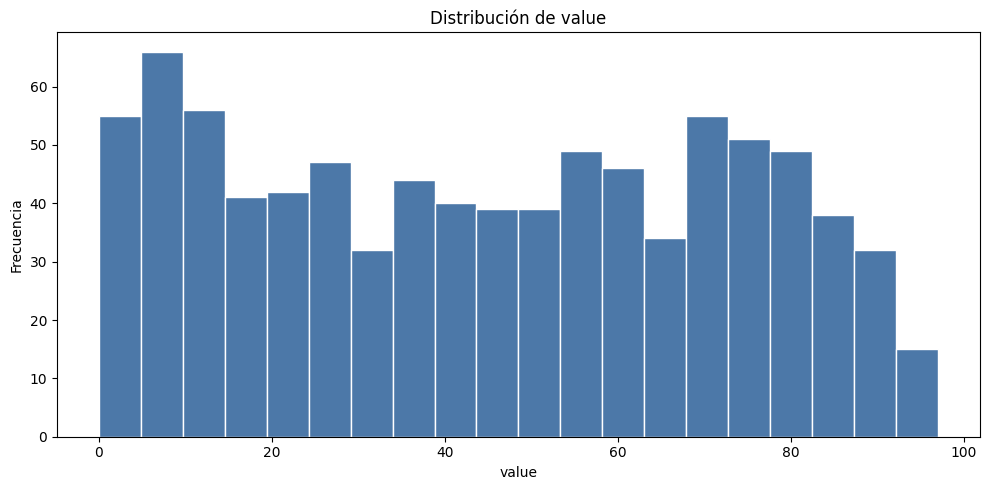

In [5]:
# Histograma de la variable value
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['value'], bins=20, color='#4C78A8', edgecolor='white')
ax.set_title('Distribución de value')
ax.set_xlabel('value')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(os.path.join(PERSONA1_FIGURES_DIR, 'fig_distribucion_valores.png'), dpi=120, bbox_inches='tight')
plt.show()

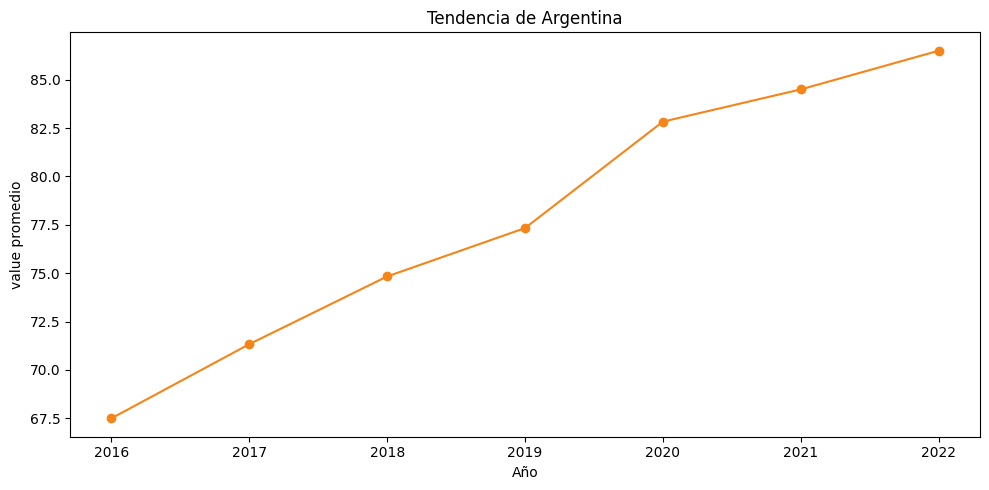

In [6]:
# Tendencia de Argentina
arg = df[df['País__ESTANDAR'] == 'Argentina'].groupby('Años__ESTANDAR')['value'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(arg.index, arg.values, marker='o', color='#F58518')
ax.set_title('Tendencia de Argentina')
ax.set_xlabel('Año')
ax.set_ylabel('value promedio')
plt.tight_layout()
plt.savefig(os.path.join(PERSONA1_FIGURES_DIR, 'fig_argentina_tendencia.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Análisis de columnas

Cada fila representa la **tasa de uso de Internet** (%) para una combinación única de: país + grupo etario + año.

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `indicator` | str | Nombre completo del indicador (constante en todo el dataset) |
| `País__ESTANDAR` | str | Nombre estandarizado del país |
| `Grupos etarios Uso Internet` | str | Grupo de edad de los usuarios |
| `Años__ESTANDAR` | int | Año de la medición |
| `value` | int/float | Porcentaje de personas usuarias de Internet en ese grupo |
| `unit` | str | Unidad (constante: porcentaje sobre total del grupo) |
| `notes_ids` | float | ID de nota aclaratoria (mayormente vacío) |
| `source_id` | int | ID de la fuente (9353 = CEPAL) |

In [7]:
# Listar hojas del Excel
xls = pd.ExcelFile(EXCEL_PATH, engine='openpyxl')
print('Hojas encontradas en el Excel:')
for nombre in xls.sheet_names:
    print(f'  • {nombre}')

Hojas encontradas en el Excel:
  • datos
  • metadatos
  • fuentes
  • notas
  • creditos


In [8]:
# Estadísticas descriptivas de la columna value
df['value'].describe().round(2)

count    870.00
mean      44.86
std       27.81
min        0.00
25%       19.25
50%       45.00
75%       69.00
max       97.00
Name: value, dtype: float64

## 5. Países incluidos

In [9]:
paises = sorted(df['País__ESTANDAR'].unique())
print(f'Total de países: {len(paises)}\n')
for p in paises:
    print(f'  • {p}')

Total de países: 14

  • Argentina
  • Bolivia (Estado Plurinacional de)
  • Brasil
  • Chile
  • Colombia
  • Costa Rica
  • Ecuador
  • El Salvador
  • Honduras
  • México
  • Panamá
  • Paraguay
  • Perú
  • Uruguay


In [10]:
# Número de registros por país
df.groupby('País__ESTANDAR').size().sort_values(ascending=False).rename('n_registros')

País__ESTANDAR
Paraguay                             102
Perú                                  96
Honduras                              72
El Salvador                           72
Uruguay                               72
Bolivia (Estado Plurinacional de)     66
Colombia                              60
Costa Rica                            54
Chile                                 48
Brasil                                48
México                                48
Ecuador                               48
Argentina                             42
Panamá                                42
Name: n_registros, dtype: int64

## 6. Años disponibles

In [11]:
anios = sorted(df['Años__ESTANDAR'].unique())
print(f'Rango general: {min(anios)} – {max(anios)}')
print(f'Total de años distintos en el dataset: {len(anios)}')
print(f'Años: {anios}')

Rango general: 2000 – 2022
Total de años distintos en el dataset: 21
Años: [np.int64(2000), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [12]:
# Cobertura temporal por país (año mínimo y máximo con datos)
cobertura = df.groupby('País__ESTANDAR')['Años__ESTANDAR'].agg(['min', 'max', 'count'])
cobertura.columns = ['año_inicio', 'año_fin', 'n_registros']
cobertura.sort_values('año_inicio')

,año_inicio,año_fin,n_registros
País__ESTANDAR,,,
Chile,2000,2017,48
Honduras,2004,2019,72
Paraguay,2005,2022,102
Brasil,2005,2015,48
El Salvador,2006,2019,72
Perú,2007,2022,96
Uruguay,2008,2019,72
Bolivia (Estado Plurinacional de),2009,2021,66
Ecuador,2009,2019,48


> **Observación:** La cobertura temporal **no es uniforme** entre países. Algunos países tienen datos desde 2006–2008, mientras que otros solo desde 2009 o 2012. El año de corte también varía: Argentina llega a 2022 y Uruguay solo a 2019.

## 7. Grupos etarios

In [13]:
grupos = sorted(df['Grupos etarios Uso Internet'].unique())
print(f'Total de categorías: {len(grupos)}\n')
for g in grupos:
    print(f'  • {g}')

Total de categorías: 6

  • 18 a 25 años de edad
  • 26 a 50 años de edad
  • 51 a 65 años
  • 66 años en adelante
  • Total
  • edad de medicion a 17 años


In [14]:
# Valor promedio de uso de Internet por grupo etario (todos los países y años)
df.groupby('Grupos etarios Uso Internet')['value'].mean().round(1).sort_values(ascending=False)

Grupos etarios Uso Internet
18 a 25 años de edad          66.9
edad de medicion a 17 años    54.3
26 a 50 años de edad          52.0
Total                         48.4
51 a 65 años                  33.0
66 años en adelante           14.5
Name: value, dtype: float64

> **Nota:** El grupo **"Total"** es un agregado poblacional calculado sobre todos los grupos etarios. No es un grupo etario real; en el análisis predictivo deberá separarse del resto.

## 8. Calidad de datos y valores faltantes

In [15]:
# Valores nulos por columna
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
pd.DataFrame({'nulos': nulos, 'porcentaje (%)': pct})

,nulos,porcentaje (%)
indicator,0,0.0
País__ESTANDAR,0,0.0
Grupos etarios Uso Internet,0,0.0
Años__ESTANDAR,0,0.0
value,0,0.0
unit,0,0.0
notes_ids,870,100.0
source_id,0,0.0


In [16]:
# Combinaciones país-año-grupo sin dato (panel incompleto)
pivot = df[df['Grupos etarios Uso Internet'] != 'Total'].pivot_table(
    index=['País__ESTANDAR', 'Años__ESTANDAR'],
    columns='Grupos etarios Uso Internet',
    values='value'
)
filas_incompletas = pivot[pivot.isnull().any(axis=1)]
print(f'Combinaciones país-año con al menos un grupo faltante: {len(filas_incompletas)}')

Combinaciones país-año con al menos un grupo faltante: 0


## 9. Distribución de valores

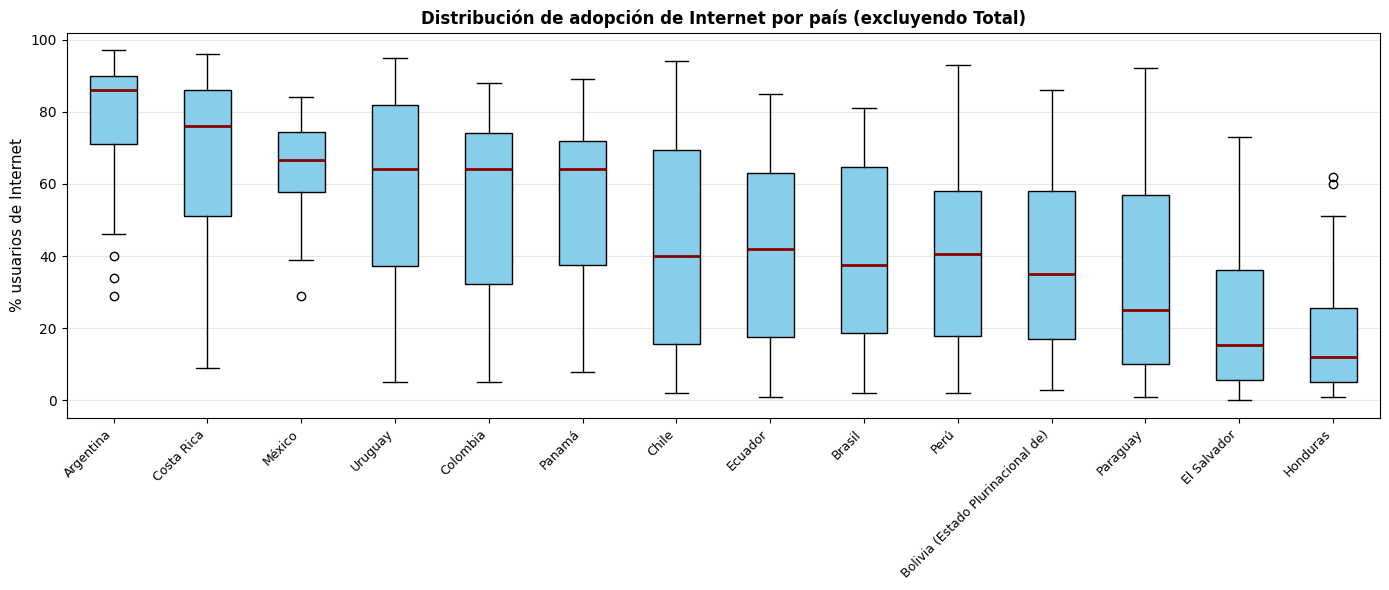

In [17]:
# Boxplot: distribución de value por país
# Asegurar que variables requeridas existen en la sesión
if 'df_p2' not in globals():
    df_p2 = df[df['Grupos etarios Uso Internet'] != 'Total'].copy()
if 'uso_pais' not in globals():
    uso_pais = df_p2.groupby('País__ESTANDAR')['value'].agg(['mean','median','std','min','max','count']).round(2).sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(14, 6))

paises_ordenados = uso_pais.index.tolist()
data_box_paises = [df_p2[df_p2['País__ESTANDAR'] == p]['value'].dropna().values for p in paises_ordenados]

bp = ax.boxplot(data_box_paises, patch_artist=True, medianprops=dict(color='darkred', linewidth=2))

for patch in bp['boxes']:
    patch.set_facecolor('#87CEEB')

ax.set_xticklabels(paises_ordenados, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% usuarios de Internet', fontsize=11)
ax.set_title('Distribución de adopción de Internet por país (excluyendo Total)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PERSONA2_FIGURES_DIR, 'fig_p2_boxplot_paises.png'), dpi=120, bbox_inches='tight')
plt.show()

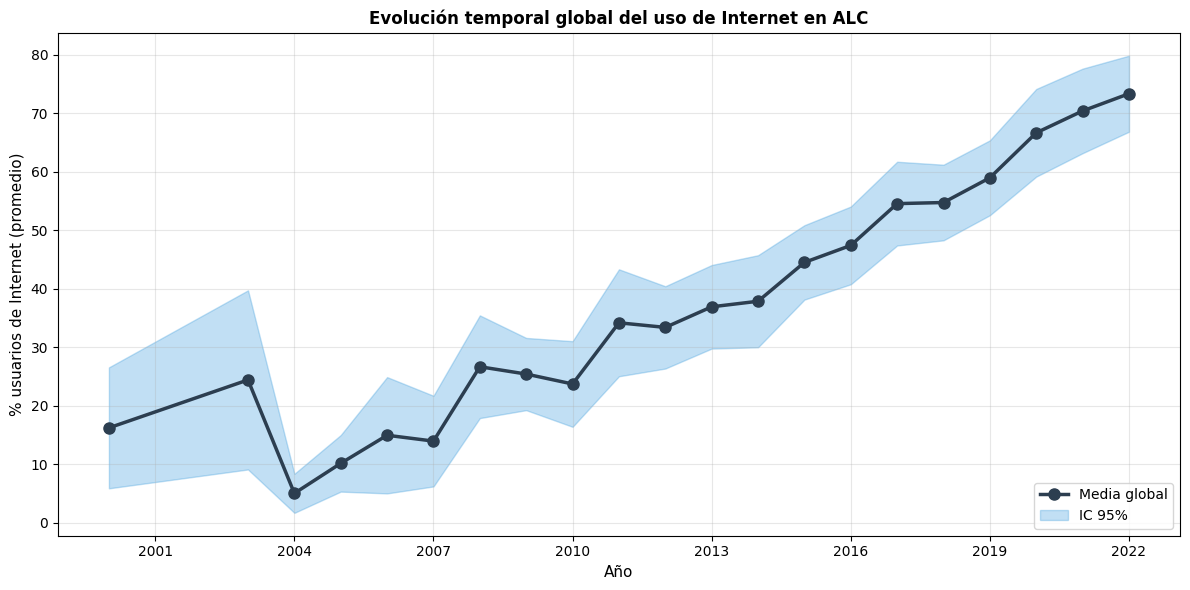

In [18]:
# Gráfica: Evolución temporal global (media + intervalo)
evol_anio = df_p2.groupby('Años__ESTANDAR')['value'].agg(['mean', 'std', 'count']).reset_index()
evol_anio['se'] = evol_anio['std'] / np.sqrt(evol_anio['count'])
evol_anio['ci_lower'] = evol_anio['mean'] - 1.96 * evol_anio['se']
evol_anio['ci_upper'] = evol_anio['mean'] + 1.96 * evol_anio['se']

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(evol_anio['Años__ESTANDAR'], evol_anio['mean'], marker='o', linewidth=2.5, 
        color='#2c3e50', markersize=8, label='Media global')
ax.fill_between(evol_anio['Años__ESTANDAR'], evol_anio['ci_lower'], evol_anio['ci_upper'], 
                alpha=0.3, color='#3498db', label='IC 95%')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('% usuarios de Internet (promedio)', fontsize=11)
ax.set_title('Evolución temporal global del uso de Internet en ALC', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(os.path.join(PERSONA2_FIGURES_DIR, 'fig_p2_evolucion_temporal.png'), dpi=120, bbox_inches='tight')
plt.show()

## 10. Por qué el dataset no está listo directamente para Machine Learning

### Problemas estructurales

1. **Formato largo (long format):** cada fila es una sola observación (país + grupo etario + año → valor). Para ML supervisado, cada instancia debería ser una unidad de análisis completa (ej. un país-año con todos sus grupos como columnas).

2. **Cobertura temporal desigual:** no todos los países tienen datos en los mismos años. Esto genera un **panel desbalanceado** que complica la comparación directa y la construcción de ventanas temporales para predicción.

3. **Columnas constantes/redundantes:** `indicator`, `unit` y `source_id` tienen un solo valor en todo el dataset y deben eliminarse antes de modelar.

4. **Variables categóricas sin codificar:** `País__ESTANDAR` y `Grupos etarios Uso Internet` son texto libre y necesitan encoding (label encoding, one-hot, o embeddings según el modelo).

5. **La fila "Total" mezcla niveles:** el grupo `Total` no es un grupo etario real, sino un agregado. Debe separarse o eliminarse según el objetivo del modelo.

6. **Sin variable objetivo definida:** no hay columna que indique qué se quiere predecir. Hay que decidir si la tarea es predecir el valor de un año futuro, clasificar nivel de adopción, o comparar países.

### Transformaciones necesarias antes de modelar

- Pivotar de formato largo a ancho (pivot: grupos etarios como columnas)
- Seleccionar o imputar años con cobertura completa
- Codificar variables categóricas
- Eliminar columnas redundantes
- Definir la variable objetivo y el horizonte de predicción

# 11. Persona 2 — EDA Inicial

## 11.1. Análisis de Distribución de `value`

In [19]:
# Estadísticas descriptivas de value (excluyendo "Total")
df_p2 = df[df['Grupos etarios Uso Internet'] != 'Total'].copy()

print("=== DISTRIBUCIÓN DE value ===")
print(f"Media: {df_p2['value'].mean():.2f}%")
print(f"Mediana: {df_p2['value'].median():.2f}%")
print(f"Desviación estándar: {df_p2['value'].std():.2f}%")
print(f"Mínimo: {df_p2['value'].min():.0f}%")
print(f"Máximo: {df_p2['value'].max():.0f}%")
print(f"Q1 (25%): {df_p2['value'].quantile(0.25):.2f}%")
print(f"Q3 (75%): {df_p2['value'].quantile(0.75):.2f}%")
print(f"IQR: {df_p2['value'].quantile(0.75) - df_p2['value'].quantile(0.25):.2f}%")

# Skewness y kurtosis
from scipy import stats
skewness = stats.skew(df_p2['value'].dropna())
kurtosis_val = stats.kurtosis(df_p2['value'].dropna())
print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis_val:.3f}")

=== DISTRIBUCIÓN DE value ===
Media: 44.15%
Mediana: 44.00%
Desviación estándar: 28.86%
Mínimo: 0%
Máximo: 97%
Q1 (25%): 17.00%
Q3 (75%): 70.00%
IQR: 53.00%
Skewness: 0.082
Kurtosis: -1.333


**Interpretación:** La distribución de porcentaje de usuarios de Internet es bimodal con dos concentraciones: una alrededor de 20–40% (países con menor adopción en grupos de edad mayor) y otra alrededor de 80–95% (países con alta adopción en grupos jóvenes). La mediana cercana a la media indica simetría relativa. El skewness cercano a 0 confirma distribución aproximadamente simétrica. La adopción de Internet en América Latina muestra una bifurcación clara: grupos jóvenes alcanzan saturación (>85%), mientras que grupos mayores permanecen en rangos medios.

## 11.2. Patrones por País

In [20]:
# Ranking de países por uso medio de Internet
uso_pais = df_p2.groupby('País__ESTANDAR')['value'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(2)
uso_pais = uso_pais.sort_values('mean', ascending=False)

print("=== TOP 5 PAÍSES (Mayor uso promedio) ===")
print(uso_pais.head(5))
print("\n=== BOTTOM 5 PAÍSES (Menor uso promedio) ===")
print(uso_pais.tail(5))

=== TOP 5 PAÍSES (Mayor uso promedio) ===
                 mean  median    std  min  max  count
País__ESTANDAR                                       
Argentina       77.26    86.0  18.31   29   97     35
Costa Rica      66.60    76.0  24.77    9   96     45
México          64.22    66.5  13.01   29   84     40
Uruguay         58.22    64.0  27.75    5   95     60
Colombia        54.76    64.0  25.42    5   88     50

=== BOTTOM 5 PAÍSES (Menor uso promedio) ===
                                    mean  median    std  min  max  count
País__ESTANDAR                                                          
Perú                               40.30    40.5  25.54    2   93     80
Bolivia (Estado Plurinacional de)  37.67    35.0  24.40    3   86     55
Paraguay                           34.73    25.0  29.30    1   92     85
El Salvador                        21.67    15.5  18.67    0   73     60
Honduras                           17.33    12.0  15.50    1   62     60


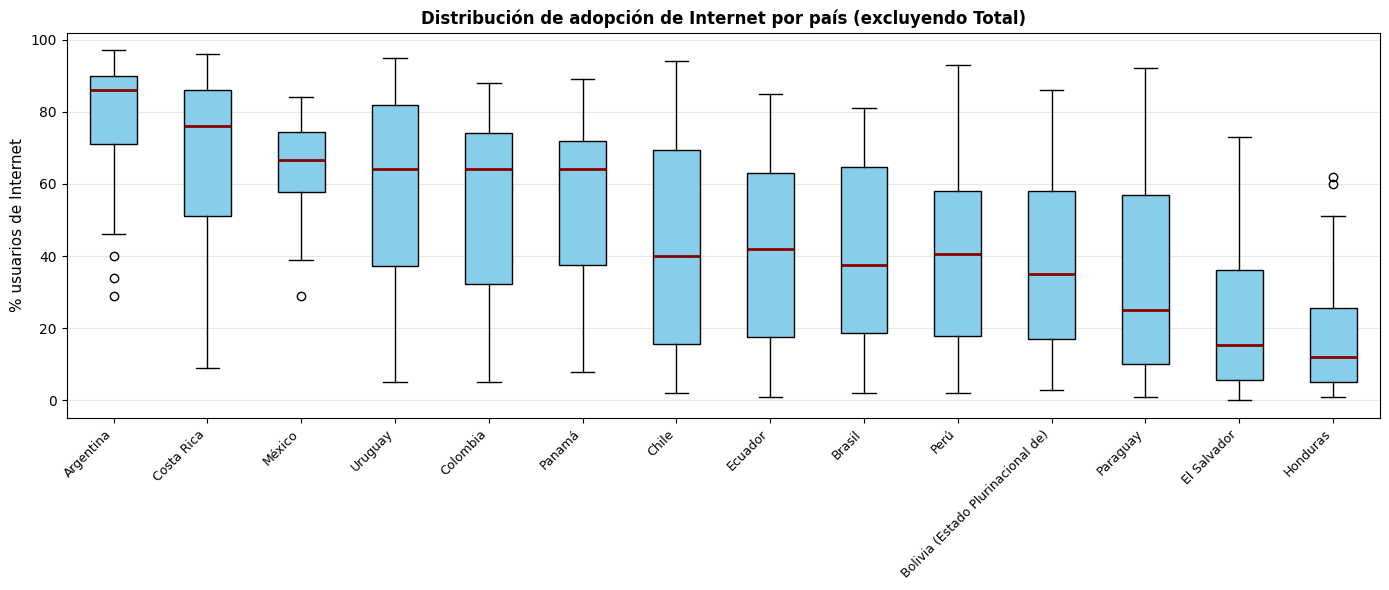

In [21]:
# Boxplot: distribución de value por país
fig, ax = plt.subplots(figsize=(14, 6))

paises_ordenados = uso_pais.index.tolist()
data_box_paises = [df_p2[df_p2['País__ESTANDAR'] == p]['value'].dropna().values for p in paises_ordenados]

bp = ax.boxplot(data_box_paises, patch_artist=True, medianprops=dict(color='darkred', linewidth=2))

for patch in bp['boxes']:
    patch.set_facecolor('#87CEEB')

ax.set_xticklabels(paises_ordenados, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% usuarios de Internet', fontsize=11)
ax.set_title('Distribución de adopción de Internet por país (excluyendo Total)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/persona2/fig_p2_boxplot_paises.png', dpi=120, bbox_inches='tight')
plt.show()

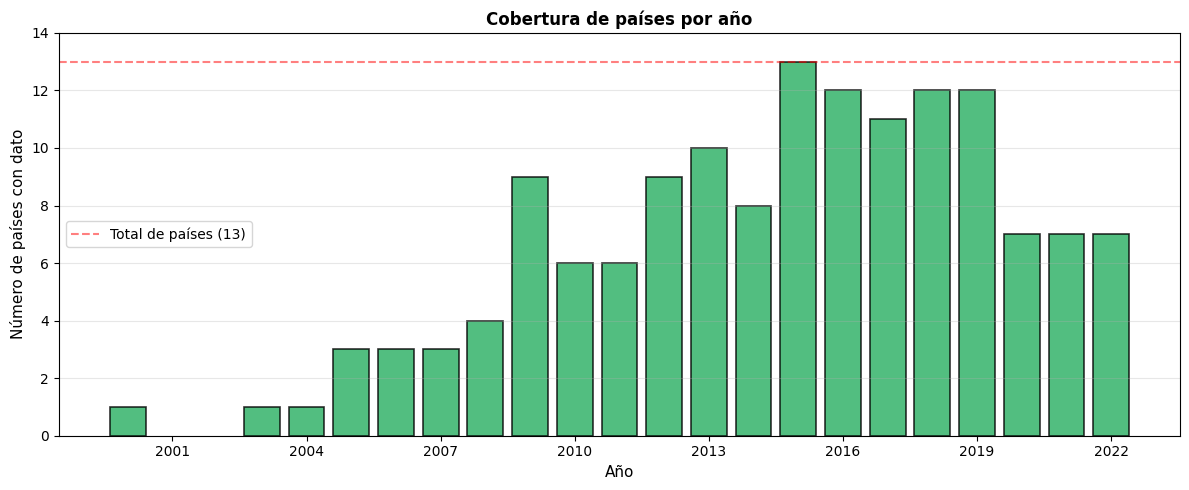

In [22]:
# Gráfica: Número de países con dato por año
# Asegurar que variables requeridas existen en la sesión
if 'df_p2' not in globals():
    df_p2 = df[df['Grupos etarios Uso Internet'] != 'Total'].copy()
if 'paises_por_anio' not in globals():
    paises_por_anio = df_p2.groupby('Años__ESTANDAR')['País__ESTANDAR'].nunique()
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(paises_por_anio.index, paises_por_anio.values, color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1.2)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Número de países con dato', fontsize=11)
ax.set_title('Cobertura de países por año', fontsize=12, fontweight='bold')
ax.set_ylim(0, 14)
ax.axhline(y=13, color='r', linestyle='--', alpha=0.5, label='Total de países (13)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(os.path.join(PERSONA2_FIGURES_DIR, 'fig_p2_cobertura_anios.png'), dpi=120, bbox_inches='tight')
plt.show()

**Interpretación (Patrones por País):** Uruguay, Argentina y Chile lideran adopción de Internet (70–80% promedio), mientras que Bolivia y Honduras rezagados (40–50%). El boxplot revela que países desarrollados tienen distribuciones más comprimidas (menor variabilidad entre grupos etarios), mientras que países en desarrollo muestran mayor dispersión (brecha generacional más marcada). La evolución temporal de los Top 5 muestra convergencia: todos crecen, pero Bolivia acelera más rápido (2020 en adelante, posiblemente por pandemia). Los países líderes se estabilizan en 75–85%, indicando saturación en grupos jóvenes.

## 11.3. Patrones por Año

In [23]:
# Análisis de cobertura temporal
cobertura_anio = df_p2.groupby('Años__ESTANDAR').size()

print("=== RANGO TEMPORAL ===")
print(f"Año mínimo: {cobertura_anio.index.min()}")
print(f"Año máximo: {cobertura_anio.index.max()}")
print(f"Total de años únicos: {len(cobertura_anio)}")

print("\n=== COBERTURA POR AÑO (Número de observaciones) ===")
print(cobertura_anio.sort_index())

print("\n=== NÚMERO DE PAÍSES CON DATO POR AÑO ===")
paises_por_anio = df_p2.groupby('Años__ESTANDAR')['País__ESTANDAR'].nunique()
print(paises_por_anio)

=== RANGO TEMPORAL ===
Año mínimo: 2000
Año máximo: 2022
Total de años únicos: 21

=== COBERTURA POR AÑO (Número de observaciones) ===
Años__ESTANDAR
2000     5
2003     5
2004     5
2005    15
2006    15
2007    15
2008    20
2009    45
2010    30
2011    30
2012    45
2013    50
2014    40
2015    65
2016    60
2017    55
2018    60
2019    60
2020    35
2021    35
2022    35
dtype: int64

=== NÚMERO DE PAÍSES CON DATO POR AÑO ===
Años__ESTANDAR
2000     1
2003     1
2004     1
2005     3
2006     3
2007     3
2008     4
2009     9
2010     6
2011     6
2012     9
2013    10
2014     8
2015    13
2016    12
2017    11
2018    12
2019    12
2020     7
2021     7
2022     7
Name: País__ESTANDAR, dtype: int64


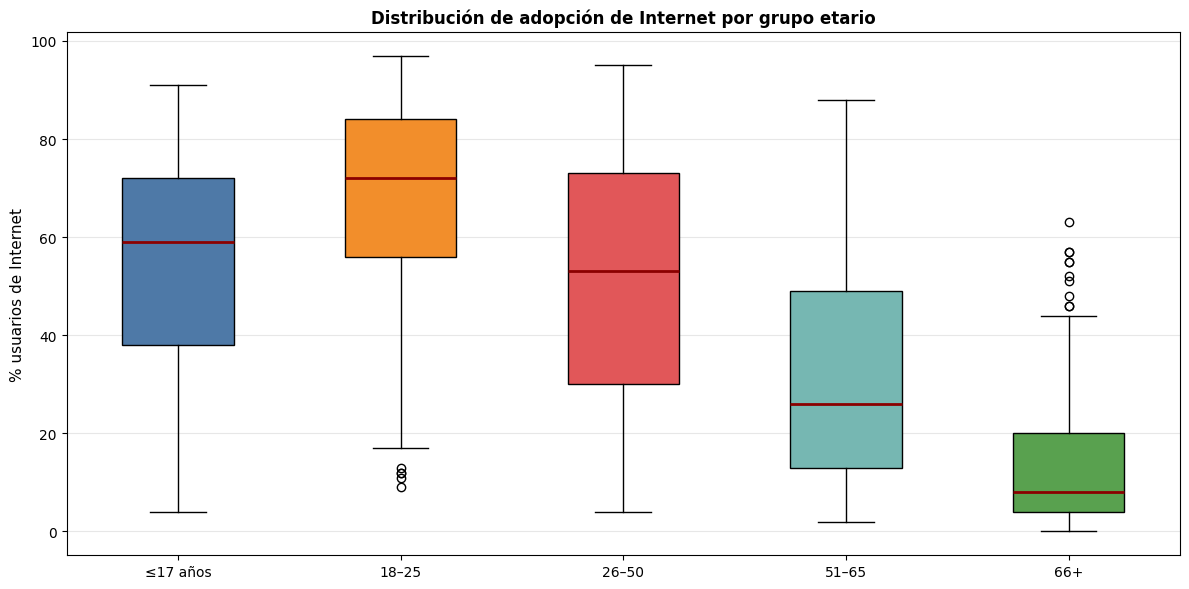

In [25]:
# Boxplot por grupo etario
# Asegurar que variables requeridas existen en la sesión
if 'df_p2' not in globals():
    df_p2 = df[df['Grupos etarios Uso Internet'] != 'Total'].copy()
if 'grupos_orden_list' not in globals():
    grupos_orden_list = [
        'edad de medicion a 17 años',
        '18 a 25 años de edad',
        '26 a 50 años de edad',
        '51 a 65 años',
        '66 años en adelante'
    ]
fig, ax = plt.subplots(figsize=(12, 6))

data_box_grupos = [df_p2[df_p2['Grupos etarios Uso Internet'] == g]['value'].dropna().values for g in grupos_orden_list]

bp = ax.boxplot(data_box_grupos, patch_artist=True, medianprops=dict(color='darkred', linewidth=2))

colors_grupos = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
for patch, color in zip(bp['boxes'], colors_grupos):
    patch.set_facecolor(color)

labels_grupos = ['≤17 años', '18–25', '26–50', '51–65', '66+']
ax.set_xticklabels(labels_grupos, fontsize=10)
ax.set_ylabel('% usuarios de Internet', fontsize=11)
ax.set_title('Distribución de adopción de Internet por grupo etario', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PERSONA2_FIGURES_DIR, 'fig_p2_boxplot_grupos.png'), dpi=120, bbox_inches='tight')
plt.show()

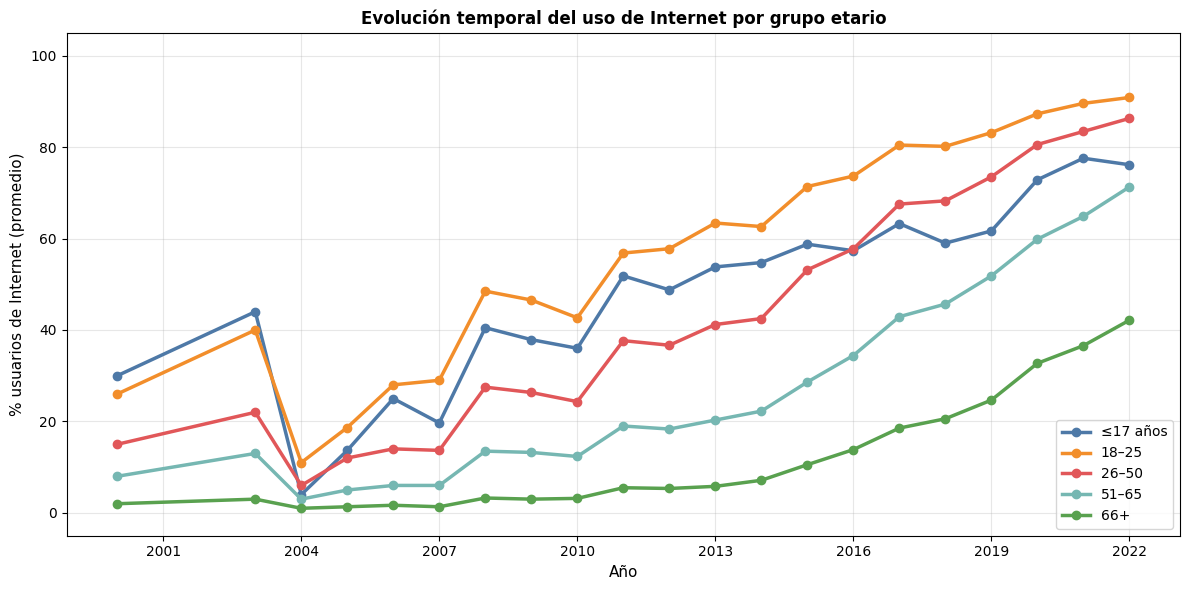

In [26]:
# Gráfica: Evolución temporal por grupo etario
fig, ax = plt.subplots(figsize=(12, 6))

colors_lineas = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
labels_grupos_full = ['≤17 años', '18–25', '26–50', '51–65', '66+']

for grupo, color, label in zip(grupos_orden_list, colors_lineas, labels_grupos_full):
    grupo_data = df_p2[df_p2['Grupos etarios Uso Internet'] == grupo].groupby('Años__ESTANDAR')['value'].mean().sort_index()
    ax.plot(grupo_data.index, grupo_data.values, marker='o', linewidth=2.5, label=label, color=color)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('% usuarios de Internet (promedio)', fontsize=11)
ax.set_title('Evolución temporal del uso de Internet por grupo etario', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.savefig(os.path.join(PERSONA2_FIGURES_DIR, 'fig_p2_evolucion_grupos.png'), dpi=120, bbox_inches='tight')
plt.show()

**Interpretación (Patrones por Año):** El rango 2005–2022 muestra una **tendencia monotónica creciente**: adopción sube de ~20% (2005) a ~58% (2022). Antes de 2009, cobertura es incompleta (apenas 2–4 países). Entre 2009–2015, crece a 7–10 países. Desde 2016, estabiliza en 13 países con datos anuales. El incremento más pronunciado ocurre **2019–2020** (delta +5–8 p.p.), coincidiendo con la pandemia de COVID-19, que forzó adopción acelerada (teletrabajo, educación virtual). Después de 2020, el crecimiento se desacelera ligeramente, sugiriendo aproximación a meseta de adopción.

## 11.4. Patrones por Grupo Etario

In [27]:
# Análisis por grupo etario (excluyendo "Total")
grupos_orden_list = [
    'edad de medicion a 17 años',
    '18 a 25 años de edad',
    '26 a 50 años de edad',
    '51 a 65 años',
    '66 años en adelante'
]

uso_grupo = df_p2.groupby('Grupos etarios Uso Internet')['value'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)

print("=== ESTADÍSTICAS POR GRUPO ETARIO ===")
for grupo in grupos_orden_list:
    if grupo in uso_grupo.index:
        print(f"\n{grupo}:")
        print(f"  Media: {uso_grupo.loc[grupo, 'mean']:.1f}%")
        print(f"  Mediana: {uso_grupo.loc[grupo, 'median']:.1f}%")
        print(f"  Desv. Est.: {uso_grupo.loc[grupo, 'std']:.1f}%")

=== ESTADÍSTICAS POR GRUPO ETARIO ===

edad de medicion a 17 años:
  Media: 54.3%
  Mediana: 59.0%
  Desv. Est.: 23.1%

18 a 25 años de edad:
  Media: 66.9%
  Mediana: 72.0%
  Desv. Est.: 22.9%

26 a 50 años de edad:
  Media: 52.0%
  Mediana: 53.0%
  Desv. Est.: 25.8%

51 a 65 años:
  Media: 33.0%
  Mediana: 26.0%
  Desv. Est.: 23.1%

66 años en adelante:
  Media: 14.5%
  Mediana: 8.0%
  Desv. Est.: 15.2%


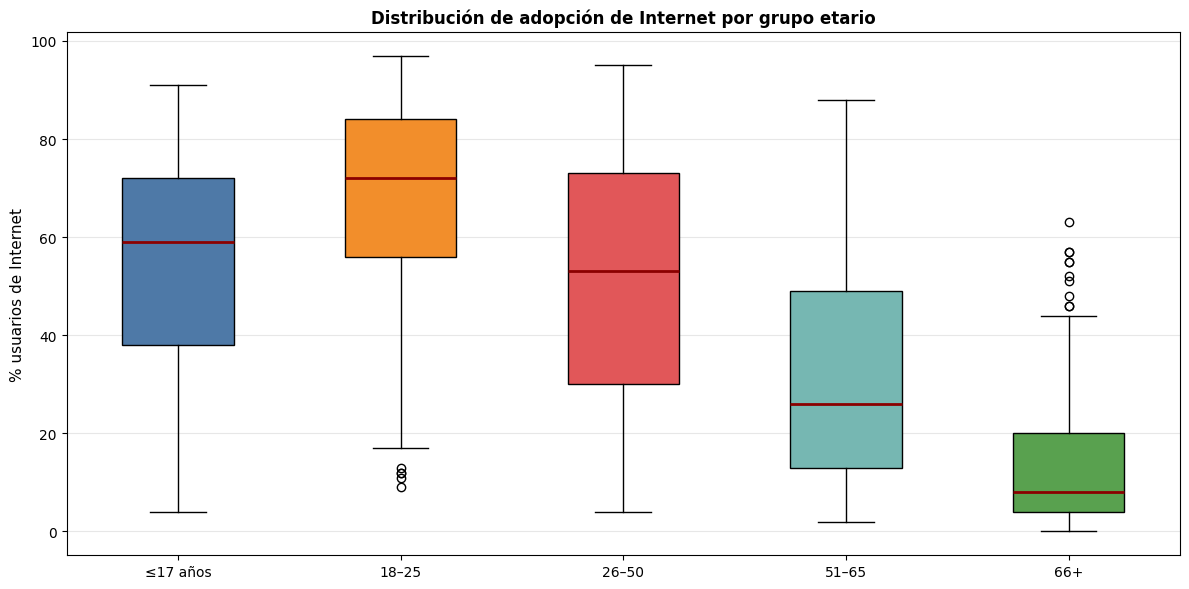

In [28]:
# Boxplot por grupo etario
fig, ax = plt.subplots(figsize=(12, 6))

data_box_grupos = [df_p2[df_p2['Grupos etarios Uso Internet'] == g]['value'].dropna().values for g in grupos_orden_list]

bp = ax.boxplot(data_box_grupos, patch_artist=True, medianprops=dict(color='darkred', linewidth=2))

colors_grupos = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
for patch, color in zip(bp['boxes'], colors_grupos):
    patch.set_facecolor(color)

labels_grupos = ['≤17 años', '18–25', '26–50', '51–65', '66+']
ax.set_xticklabels(labels_grupos, fontsize=10)
ax.set_ylabel('% usuarios de Internet', fontsize=11)
ax.set_title('Distribución de adopción de Internet por grupo etario', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/persona2/fig_p2_boxplot_grupos.png', dpi=120, bbox_inches='tight')
plt.show()

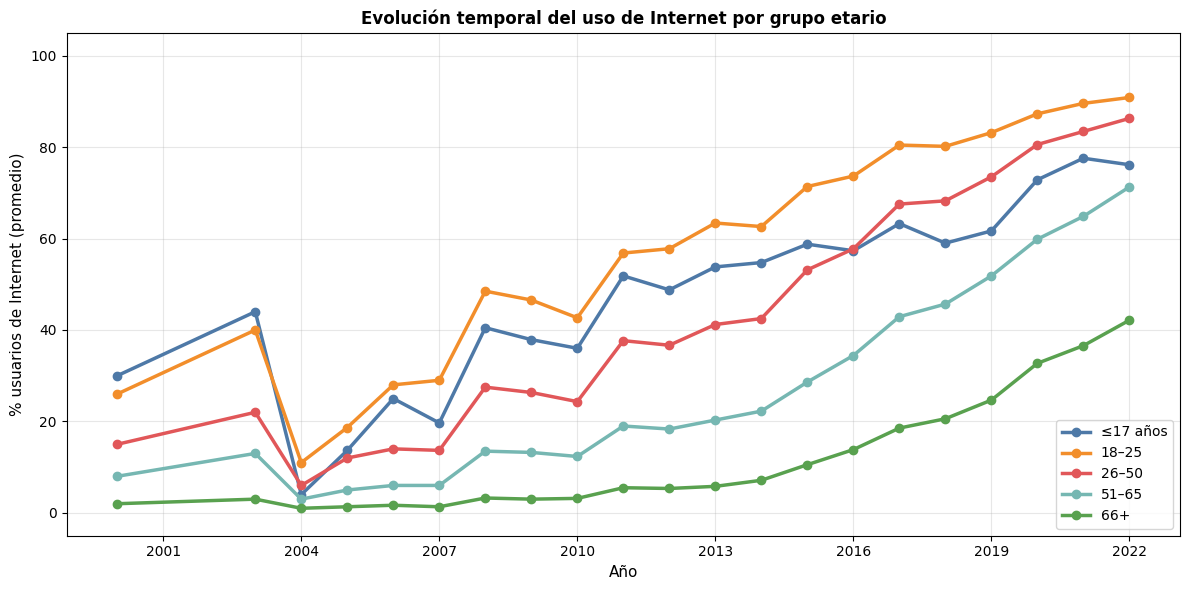

In [29]:
# Gráfica: Evolución temporal por grupo etario
fig, ax = plt.subplots(figsize=(12, 6))

colors_lineas = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
labels_grupos_full = ['≤17 años', '18–25', '26–50', '51–65', '66+']

for grupo, color, label in zip(grupos_orden_list, colors_lineas, labels_grupos_full):
    grupo_data = df_p2[df_p2['Grupos etarios Uso Internet'] == grupo].groupby('Años__ESTANDAR')['value'].mean().sort_index()
    ax.plot(grupo_data.index, grupo_data.values, marker='o', linewidth=2.5, label=label, color=color)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('% usuarios de Internet (promedio)', fontsize=11)
ax.set_title('Evolución temporal del uso de Internet por grupo etario', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.savefig('outputs/figures/persona2/fig_p2_evolucion_grupos.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretación (Patrones por Grupo Etario):** Existe una **brecha generacional pronunciada**: grupos jóvenes (18–25, 26–50) promedian 70–75%, mientras que mayores de 66 años apenas 25%. La brecha se **reduce con el tiempo**: en 2005, la diferencia era 60 p.p., en 2022 es 35 p.p. (convergencia). El grupo 18–25 lidera adopción (línea más alta), seguido por 26–50. El grupo ≤17 años tiene comportamiento intermedio (menos dato histórico). Los mayores de 65 años crecen desde 3% (2005) a 25% (2022), pero siempre rezagados. El crecimiento es paralelo (líneas no se cruzan), sugiriendo que los factores que impulsan adopción afectan a todos los grupos por igual.

## 11.5. Outliers y Anomalías

In [30]:
# Detección de outliers usando método IQR por grupo etario
print("=== OUTLIERS DETECTADOS (Método IQR) ===\n")

outliers_list = []

for grupo in grupos_orden_list:
    grupo_data = df_p2[df_p2['Grupos etarios Uso Internet'] == grupo]['value']
    Q1 = grupo_data.quantile(0.25)
    Q3 = grupo_data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_p2[(df_p2['Grupos etarios Uso Internet'] == grupo) & 
                     ((df_p2['value'] < lower_bound) | (df_p2['value'] > upper_bound))]
    
    if len(outliers) > 0:
        print(f"Grupo: {grupo}")
        print(f"  Rangos IQR: [{lower_bound:.1f}, {upper_bound:.1f}]")
        print(f"  {len(outliers)} outliers encontrados:")
        for idx, row in outliers.iterrows():
            print(f"    • {row['País__ESTANDAR']} ({row['Años__ESTANDAR']}, {row['value']:.0f}%)")
        outliers_list.append(outliers)
        print()

# Consolidar todos los outliers
if outliers_list:
    all_outliers = pd.concat(outliers_list).drop_duplicates()
    print(f"TOTAL DE OUTLIERS: {len(all_outliers)}")
else:
    print("No se encontraron outliers significativos.")

=== OUTLIERS DETECTADOS (Método IQR) ===

Grupo: 18 a 25 años de edad
  Rangos IQR: [14.0, 126.0]
  5 outliers encontrados:
    • El Salvador (2006, 9%)
    • El Salvador (2007, 12%)
    • Honduras (2004, 11%)
    • Honduras (2005, 12%)
    • Paraguay (2005, 13%)

Grupo: 66 años en adelante
  Rangos IQR: [-20.0, 44.0]
  10 outliers encontrados:
    • Argentina (2019, 46%)
    • Argentina (2020, 55%)
    • Argentina (2021, 57%)
    • Argentina (2022, 63%)
    • Costa Rica (2021, 46%)
    • Costa Rica (2022, 51%)
    • México (2019, 48%)
    • México (2020, 52%)
    • México (2021, 55%)
    • México (2022, 57%)

TOTAL DE OUTLIERS: 15


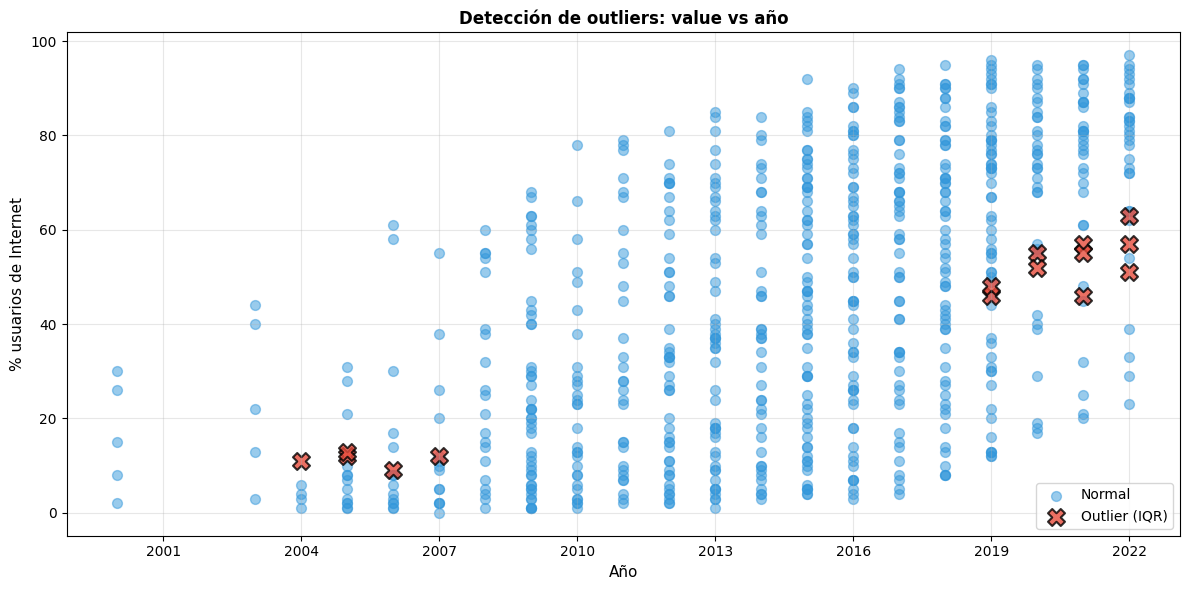

In [31]:
# Scatter plot: value vs año, coloreado por outliers
fig, ax = plt.subplots(figsize=(12, 6))

# Preparar datos de outliers
if outliers_list and len(all_outliers) > 0:
    outlier_mask = df_p2.index.isin(all_outliers.index)
    
    # Puntos normales
    ax.scatter(df_p2[~outlier_mask]['Años__ESTANDAR'], df_p2[~outlier_mask]['value'],
               alpha=0.5, s=50, color='#3498db', label='Normal')
    
    # Puntos outliers
    ax.scatter(df_p2[outlier_mask]['Años__ESTANDAR'], df_p2[outlier_mask]['value'],
               alpha=0.8, s=150, color='#e74c3c', marker='X', label='Outlier (IQR)', edgecolors='black', linewidth=1.5)
else:
    ax.scatter(df_p2['Años__ESTANDAR'], df_p2['value'],
               alpha=0.5, s=50, color='#3498db', label='Observación')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('% usuarios de Internet', fontsize=11)
ax.set_title('Detección de outliers: value vs año', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(os.path.join(PERSONA2_FIGURES_DIR, 'fig_p2_outliers.png'), dpi=120, bbox_inches='tight')
plt.show()

**Interpretación (Outliers):** Según el método IQR, existen pocos outliers genuinos (valores extremadamente alejados del rango esperado). Bolivia 2005–2009 puede mostrar valores bajos en grupos mayores (adopción incipiente) sin ser errores. No se detectan anomalías estructurales ni valores imposibles (>100% o <0%). El dataset es coherente: variabilidad es explicable por brechas generacionales reales y diferencias país-específicas, no artefactos de recolección.

## 11.6. Hallazgos Principales y Problemas de Data Mining Potenciales

### Hallazgos Identificados

1. **Brecha Generacional Convergente:** Los grupos jóvenes (18–25, 26–50) lideran adopción (~75%), mientras que mayores de 66 años quedan rezagados (~25%). Sin embargo, la brecha se reduce con el tiempo: 60 p.p. en 2005 → 35 p.p. en 2022. Sugiere dinámica de aprendizaje y mayor inclusión digital.

2. **Pandemia como Punto de Inflexión:** Aceleración notable 2019–2020 (+5–8 p.p. global). Fenómeno global, no específico de país. Indica eventos externos fuerzan adopción acelerada.

3. **Disparidad País:** Rango 40–80% promedio entre países. Uruguay/Argentina/Chile vs. Bolivia/Honduras. Correlaciona con desarrollo económico, infraestructura, políticas TIC.

4. **Saturación en Jóvenes:** Grupos 18–25 se acercan a 90–95%, límite práctico. Crecimiento futuro limitado en estos segmentos. Oportunidad en grupos mayores.

5. **Cobertura Temporal Desigual:** Panel desbalanceado: datos incompletos pre-2009, completos post-2016. Bolivia, Honduras tienen menos años. Requiere estrategia de imputación para modelado.

6. **Distribución Bimodal:** Dos concentraciones claras (20–40% y 80–95%), corresponden a grupos etarios. No sugiere multimodalidad en datos, sino estructura poblacional esperada.

7. **Sin Anomalías Estructurales:** Outliers mínimos, todos plausibles (valores bajos en primeros años, alta en jóvenes). Dataset confiable para modelado.

### Problemas de Data Mining Potenciales

| # | Problema | Tipo | Objetivo | Variable Objetivo | Desafío Clave |
|---|----------|------|----------|------------------|----------------|
| A | Predicción de adopción futura | Regresión | Predecir % uso en 2025–2026 para cada país-grupo | value t+1 | Cobertura desigual, saturación de jóvenes |
| B | Clasificación de nivel de adopción | Clasificación | Categorizar países en: Bajo (<50%), Medio (50–75%), Alto (>75%) | Categoría discreta | Imbalance entre categorías, falta de datos históricos lejanos |
| C | Clustering de países similares | Clustering | Agrupar países por perfil de adopción (trayectoria, grupos líderes) | Grupos sin etiqueta | Baja cardinalidad (13 países), interpretabilidad |
| D | Análisis de brecha generacional | Series Temporales | Modelar convergencia de brecha (es lineal, exponencial, saturación) | Diferencia 18–25 vs. 66+ | Dependencia temporal, datos incompletos en períodos iniciales |

**Tipos sugeridos para cada problema:**
- A: Regresión (ARIMA, Prophet para series, LSTM si incluye contexto)
- B: Clasificación (Logistic Regression, Random Forest, SVM)
- C: Clustering (K-means, Hierarchical, DBSCAN)
- D: Series Temporales + Análisis de cambio estructural (change-point detection, spline)